---
title: "Hands-On Machine Learning di STATA 19"
date: 2025-08-08
author: Deri Siswara
toc: true
categories:
  - STATA
  - Machine Learning
---

## Pendahuluan

**STATA 19** telah mendukung fitur *machine learning* dengan metode/framework [*H2O machine learning*](https://www.stata.com/new-in-stata/machine-learning-h2o-ensemble-decision-trees/). H2OML memungkinkan penggunaan machine learning melalui H2O untuk menemukan insight dari data ketika model statistik tradisional tidak lagi memadai. H2O menggunakan ensemble decision trees—seperti Gradient Boosting Machine (GBM) dan Random Forest—untuk melakukan klasifikasi atau regresi. Pada H2O terdapat tuning hiperparameter, validasi atau cross-validation (CV), evaluasi kinerja model, prediksi, dan *explainable ML*.

## Data

Dataset pada *Hands-On* ini menggunakan **data artificial survei pendapatan di Indonesia** untuk **mengklasifikasikan** apakah pendapatan tahunan seorang individu **> Rp100 juta** berdasarkan atribut/peubah demografis. Detil informasi dapat dapat diakses [DI SINI](https://derisiswara.github.io/blog/2025_08_08_data_pendapatan/) dan bisa diunduh pada tautan di bawah ini.

<a href="pendapatan.xlsx" download class="btn btn-primary">📥 Download Dataset</a>

## Overview H2O Machine Learning  di STATA 19

Pada *Hands-On* ini, kita akan menggunakan *stata code* dibandingkan dengan fitur GUI yang disediakan oleh STATA 19. Akan tetapi, sebagai gambaran umum, fitur GUI H2O di STATA 19 juga menyediakan antarmuka yang ramah pengguna untuk melakukan analisis machine learning tanpa perlu menulis kode secara manual. Overview end-to-end hands-on ini selain bisa mengikuti tulisan ini, atau bisa juga melihat video singkat di bawah ini.

{{< video https://youtu.be/bNHLIgw9hVI  >}}

## Hands-On Machine Learning di STATA 19

::: {.callout-note}

*Hands-On* ini tidak menjelaskan detil terkait teori atau interpretasi *Machine Learning*. Hanya menggambarkan workflow *Machine Learning* secara general. 

:::

### Import Data dan Preprocessing

In [1]:
* import data
import excel "pendapatan.xlsx", firstrow clear
describe

(8 vars, 32,561 obs)

Contains data
 Observations:        32,561                  
    Variables:             8                  
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
umur            byte    %10.0g                umur
jenis_pekerjaan str10   %10s                  jenis_pekerjaan
pendidikan      str10   %10s                  pendidikan
status_perkaw~n str13   %13s                  status_perkawinan
jenis_kelamin   str9    %9s                   jenis_kelamin
jam_kerja_min~u byte    %10.0g                jam_kerja_minggu
pulau_asal      str18   %18s                  pulau_asal
pendapatan      str9    %9s                   pendapatan
-------------------------------------------------------------------------------
Sorted by: 
     Note: Dataset has changed since last sav

In [2]:
* Hapus observasi dengan missing values
misstable summarize

foreach var of varlist _all {
    drop if missing(`var')
}

count

(variables nonmissing or string)
(0 observations deleted)
(1,836 observations deleted)
(0 observations deleted)
(0 observations deleted)
(0 observations deleted)
(0 observations deleted)
(556 observations deleted)
(0 observations deleted)
  30,169


### Inisialisasi dan Persiapan Data pada H2O

H2O di STATA 19 mempunyai cluster/framework khusus, sehingga perlu persiapan berupa inisialisasi cluster H2O, pengunggahan dataset dari memori Stata ke H2O frame, serta penetapan frame aktif yang akan digunakan dalam proses pemodelan.

In [3]:
* Inisialisasi H2O
h2o init

* Unggah dataset yang sudah di-import dari memori STATA ke H2O
_h2oframe put, into(pendapatan) replace

* Tetapkan frame aktif
_h2oframe change pendapatan

Connecting to the H2O cluster running at http://127.0.0.1:54321.....not found.
Starting a new cluster running at http://127.0.0.1:54321.
Connecting to the H2O cluster running at http://127.0.0.1:54321... Successful.
------------------------------------------------------------------------------
H2O cluster uptime:        2 secs
H2O cluster timezone:      Asia/Jakarta
H2O data parsing timezone: UTC
H2O cluster version:       3.46.0.7
H2O cluster version age:   4 months and 12 days
H2O cluster total nodes:   1
H2O cluster free memory:   3.864 Gb
H2O cluster total cores:   18
H2O cluster allowed cores: 18
H2O cluster status:        accepting new members, healthy
H2O connection url:        http://127.0.0.1:54321
------------------------------------------------------------------------------

Progress (%): 0 100


### Convert Data

Convert `str` to `enum`. H2O tidak otomatis tahu bahwa setiap peubah merupakan data kategori sehingga perlu diconvert ke kategori di frame H2O.

In [ ]:
* Convert jenis data
_h2oframe toenum jenis_pekerjaan pendidikan status_perkawinan jenis_kelamin pulau_asal pendapatan, replace

### Split Data

In [5]:
*Split data → train/test (80/20), jadikan train sebagai current frame
_h2oframe split pendapatan, into(train test) split(0.8 0.2) rseed(19)
_h2oframe change train

Perintah `_h2oframe split` digunakan untuk membagi *H2O frame* aktif menjadi dua subset, yaitu `train` dan `test`, dengan proporsi 80% untuk *training* dan 20% untuk *testing*, menggunakan *random seed* 19 agar pembagian data dapat direplikasi. Pembagian ini memastikan bahwa data untuk pelatihan dan pengujian model terpisah, sehingga evaluasi kinerja model lebih objektif. Selanjutnya, `_h2oframe change train` menetapkan frame `train` sebagai *current frame* di H2O, sehingga semua perintah pemodelan berikutnya akan secara default menggunakan subset data *training* tersebut.


### Train Model

Pada *hands-on* ini kita akan menggunakan algoritme **Random Forest** dengan parameter default.

In [6]:
global X pendidikan umur jenis_pekerjaan status_perkawinan ///
        jenis_kelamin jam_kerja_minggu pulau_asal
h2oml rfbinclass pendapatan $X, h2orseed(19) cv(5, stratify)
h2omlest store rf_cv            


Progress (%): 0 1.6 5.0 8.3 20.6 46.6 81.9 83.3 87.0 93.9 100

Random forest binary classification using H2O

Response: pendapatan
Frame:                                 Number of observations:
  Training: train                                  Training = 24,228
                                           Cross-validation = 24,228
Cross-validation: Stratify             Number of folds      =      5

Model parameters

Number of trees      =   50
              actual =   50
Tree depth:                            Pred. sampling value =     -1
           Input max =   20            Sampling rate        =   .632
                 min =   20            No. of bins cat.     =  1,024
                 avg = 20.0            No. of bins root     =  1,024
                 max =   20            No. of bins cont.    =     20
Min. obs. leaf split =    1            Min. split thresh.   = .00001

Metric summary
------------------------------------------
                  |                 Cross-
       

Perintah `global X` digunakan untuk membuat *global macro* bernama **X** yang berisi daftar variabel prediktor, sehingga setiap kali dipanggil dengan `$X` akan otomatis diganti oleh daftar variabel tersebut. Selanjutnya, perintah `h2oml rfbinclass pendapatan $X, h2orseed(19) cv(5, stratify)` melatih model **Random Forest** klasifikasi biner dengan target `pendapatan` dan prediktor pada macro `$X`, menggunakan *cross-validation* 5-fold yang dibagi secara **stratified** agar proporsi kelas tetap seimbang di tiap fold, serta *seed* 19 agar hasil dapat direplikasi. Terakhir, `h2omlest store rf_cv` menyimpan model hasil pelatihan tersebut dengan nama `rf_cv` di memori, sehingga dapat digunakan kembali untuk evaluasi, prediksi pada data baru, atau perbandingan dengan model lain tanpa perlu melatih ulang.


### Evaluasi Model

Untuk mengevaluasi kinerja model, kita perlu mengaktifkan frame data *test* dan restore model yang sudah dilatih. Setelah itu, kita dapat menggunakan berbagai fungsi untuk mendapatkan metrik evaluasi model, seperti:

* `h2omlestat metrics` — Menampilkan ringkasan metrik kinerja (mis. AUC/ROC, AUCPR, logloss ) **pada frame yang aktif**.
* `h2omlestat confmatrix` — Menampilkan **confusion matrix** pada **ambang (threshold)** yang sedang dipakai.
* `h2omlestat threshmetric` — Menghitung berbagai metrik di threshold terbaik.
* `h2omlgraph roc` — Menggambar **kurva ROC** dan menampilkan **AUC** untuk menilai trade-off TPR vs FPR.
* `h2omlgraph prcurve` — Menggambar **kurva Precision–Recall** dan menampilkan **AUCPR**; khususnya lebih informatif untuk data yang **imbalanced**.



In [9]:
* Aktivasi data test dan restore model
h2omlpostestframe test  
h2omlest restore rf_cv

(testing frame test is now active for h2oml postestimation)
(results rf_cv are active now)


In [8]:
h2omlestat metrics


Performance metrics using H2O
Random forest binary classification

Response:      pendapatan
Testing frame: test

Number of observations = 5,941

------------------------------
           Metric |    Testing
------------------+-----------
         Log loss |   .3918207
 Mean class error |   .2122307
              AUC |   .8617035
            AUCPR |   .6507635
 Gini coefficient |   .7234071
              MSE |   .1282224
             RMSE |   .3580816
------------------------------


In [10]:
h2omlestat confmatrix


Confusion matrix using H2O
Testing frame: test

            |      Predicted
 pendapatan |  <=100juta   >100juta |  Total  Error    Rate
------------+-----------------------+----------------------
  <=100juta |      3,304      1,115 |  4,419  1,115    .252
   >100juta |        262      1,260 |  1,522    262    .172
------------+-----------------------+----------------------
      Total |      3,566      2,375 |  5,941  1,377    .232

Note: Probability threshold .2822 that maximizes F1 metric
      used for classification.



In [11]:
h2omlestat threshmetric


Maximum or minimum metrics using H2O
Testing frame: test
------------------------------------------
              Metric |  Max/Min  Threshold
---------------------+--------------------
                  F1 |    .6467      .2822
                  F2 |    .7683      .1338
                F0.5 |    .6323      .4943
            Accuracy |    .8113      .4707
           Precision |        1      .9594
              Recall |        1      .0085
         Specificity |        1      .9594
 Min. class accuracy |    .7799      .3187
 Mean class accuracy |     .788      .2068
      True negatives |     4419      .9594
     False negatives |        0      .0085 +
      True positives |     1522      .0085
     False positives |        0      .9594 +
  True-negative rate |        1      .9594
 False-negative rate |        0      .0085 +
  True-positive rate |        1      .0085
 False-positive rate |        0      .9594 +
                 MCC |    .5129      .2822
-------------------------------

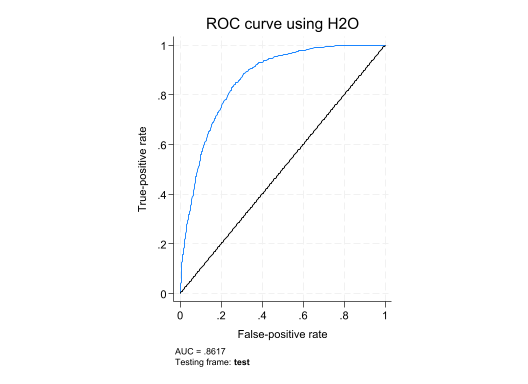

In [12]:
h2omlgraph roc

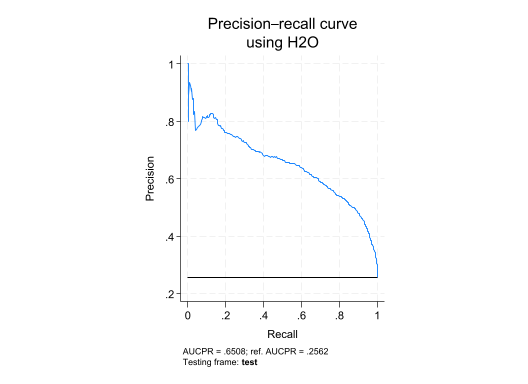

In [13]:
h2omlgraph prcurve

### Explainable ML

Karena H2O merupakan model *ensamble learning* berbasis pohon, maka di STATA 19 juga bisa ditampilkan explainable ML seperti variabel importance (`h2omlgraph varimp`) dan SHAP (`h2omlgraph shapsummary`).

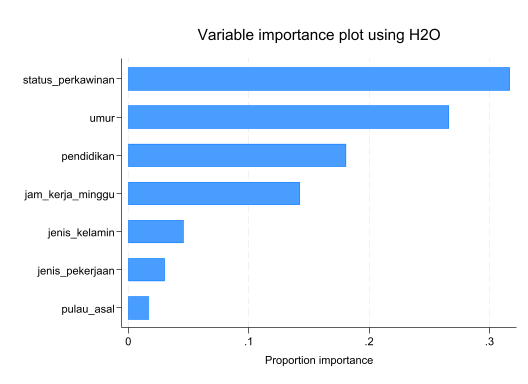

In [14]:
h2omlgraph varimp 


Progress (%): 0 100


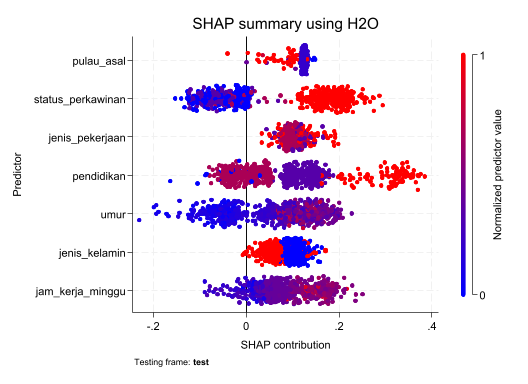

In [16]:
h2omlgraph shapsummary

## Penutup

Satu fitur lagi yang dapat digunakan adalah menghasilkan prediksi *fitted value* baik dalam bentuk kelas maupun probabilitas menggunakan perintah `h2omlpredict`. Prediksi juga dapat dilakukan pada *data frame* baru yang belum pernah digunakan saat pelatihan model.

Salah satu keterbatasan *machine learning* di STATA 19 adalah penggunaannya yang lebih cocok untuk analisis data dan eksplorasi (*inferensi* atau riset) dibanding untuk kebutuhan *deployment* model ke sistem produksi. STATA 19 belum menyediakan dukungan penuh untuk integrasi atau *deployment* model secara langsung ke dalam *framework* lain. Oleh karena itu, untuk kebutuhan *deployment* yang lebih luas, biasanya model dibangun atau diekspor menggunakan bahasa/program lain seperti **R** atau **Python**.

*Keep curious and happy repo diving!*